# Anomaly Detection and Smart Consumption Profiling in Energy Utility Systems Using Machine Learning and Big Data Technologies

---



---



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import KMeans
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, confusion_matrix, classification_report, roc_curve, auc, accuracy_score

from prophet import Prophet

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

from matplotlib_venn import venn3
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


warnings.filterwarnings('ignore')


In [3]:

# Load data
file_path = '/content/drive/MyDrive/Colab Notebooks/household_power_consumption.txt'
df = pd.read_csv(
    file_path,
    sep=';',
    parse_dates={'datetime': ['Date', 'Time']},
    dayfirst=True,
    infer_datetime_format=True,
    na_values=['?'],
    low_memory=False
)
df.set_index('datetime', inplace=True)
df = df[['Global_active_power','Global_reactive_power','Voltage','Global_intensity','Sub_metering_1','Sub_metering_2','Sub_metering_3']]
df = df.apply(pd.to_numeric, errors='coerce')
df.dropna(inplace=True)


# 📊 Exploratory Data Analysis (EDA)

In [4]:
# Summary statistics
print("📌 Dataset Overview:")
display(df.describe())

# Missing values
print("\n🔍 Missing Value Count:")
print(df.isna().sum())

# Check data types and date range
print("\n📆 Date Range:")
print(f"From {df.index.min()} to {df.index.max()}")

print("\n📐 Data Types:")
print(df.dtypes)


📌 Dataset Overview:


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06
mean,1.091615e+00,1.237145e-01,2.408399e+02,4.627759e+00,1.121923e+00,1.298520e+00,6.458447e+00
std,1.057294e+00,1.127220e-01,3.239987e+00,4.444396e+00,6.153031e+00,5.822026e+00,8.437154e+00
min,7.600000e-02,0.000000e+00,2.232000e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.080000e-01,4.800000e-02,2.389900e+02,1.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,6.020000e-01,1.000000e-01,2.410100e+02,2.600000e+00,0.000000e+00,0.000000e+00,1.000000e+00
75%,1.528000e+00,1.940000e-01,2.428900e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01
max,1.112200e+01,1.390000e+00,2.541500e+02,4.840000e+01,8.800000e+01,8.000000e+01,3.100000e+01



🔍 Missing Value Count:
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64

📆 Date Range:
From 2006-12-16 17:24:00 to 2010-11-26 21:02:00

📐 Data Types:
Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
dtype: object


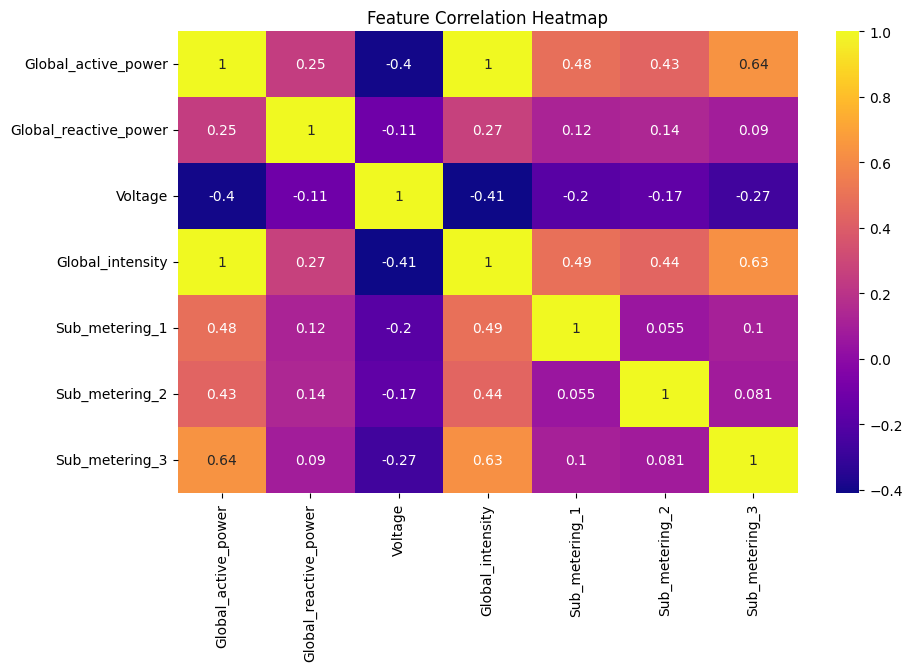

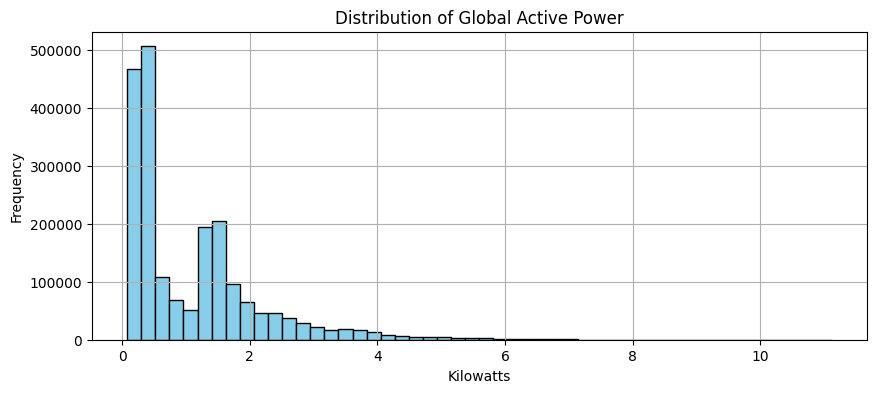

In [5]:
# 🔥 Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df[['Global_active_power', 'Global_reactive_power', 'Voltage',
                'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
                'Sub_metering_3']].corr(), annot=True, cmap='plasma')
plt.title("Feature Correlation Heatmap")
plt.show()

# ⚡ Histogram of Global Active Power
df['Global_active_power'].dropna().plot(kind='hist', bins=50, figsize=(10,4),
                                        color='skyblue', edgecolor='black')
plt.title("Distribution of Global Active Power")
plt.xlabel("Kilowatts")
plt.grid()
plt.show()



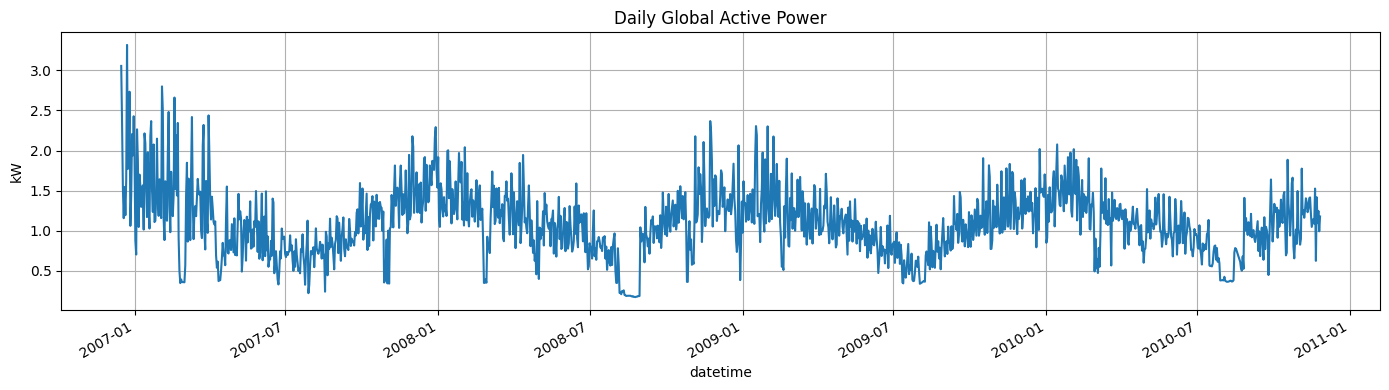

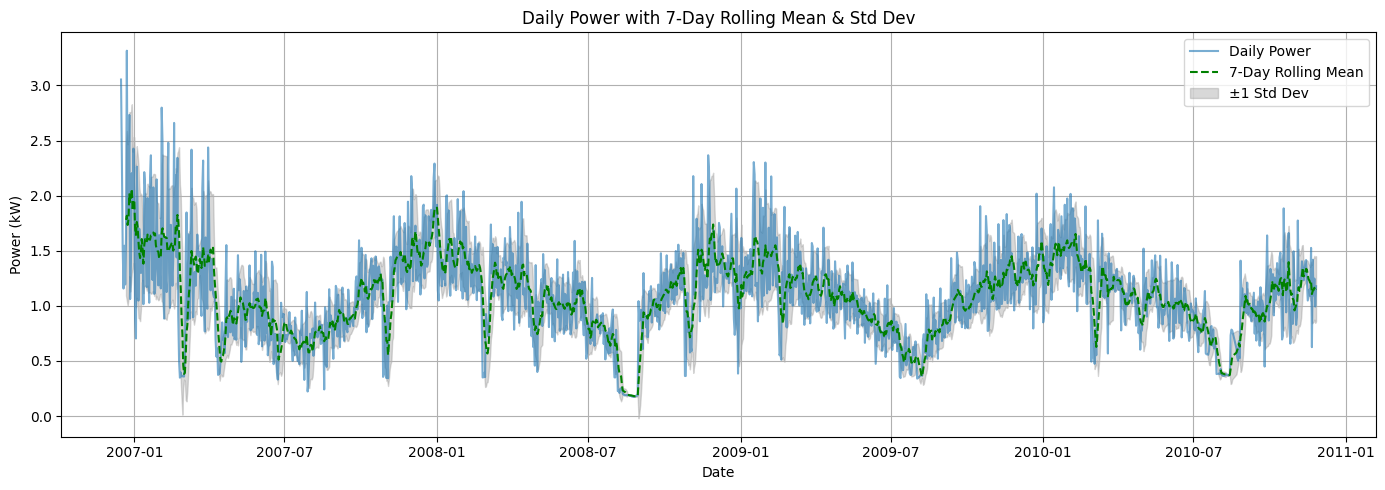

In [6]:
# 📅 Resample to daily average
df_daily = df['Global_active_power'].resample('D').mean().dropna()
df_daily = df_daily.to_frame(name='power')

# 📈 Plot daily power
plt.figure(figsize=(14, 4))
df_daily['power'].plot(title='Daily Global Active Power')
plt.ylabel('kW')
plt.grid()
plt.tight_layout()
plt.show()

# 🔁 Rolling mean and std (7-day)
df_daily['rolling_mean'] = df_daily['power'].rolling(window=7).mean()
df_daily['rolling_std'] = df_daily['power'].rolling(window=7).std()

plt.figure(figsize=(14, 5))
plt.plot(df_daily.index, df_daily['power'], label='Daily Power', alpha=0.6)
plt.plot(df_daily.index, df_daily['rolling_mean'], label='7-Day Rolling Mean', linestyle='--', color='green')
plt.fill_between(df_daily.index,
                 df_daily['rolling_mean'] - df_daily['rolling_std'],
                 df_daily['rolling_mean'] + df_daily['rolling_std'],
                 color='gray', alpha=0.3, label='±1 Std Dev')
plt.title("Daily Power with 7-Day Rolling Mean & Std Dev")
plt.xlabel("Date")
plt.ylabel("Power (kW)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


# Data Overview & Time-Series Plots

Dataset shape: (2049280, 7)
Missing values:
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64


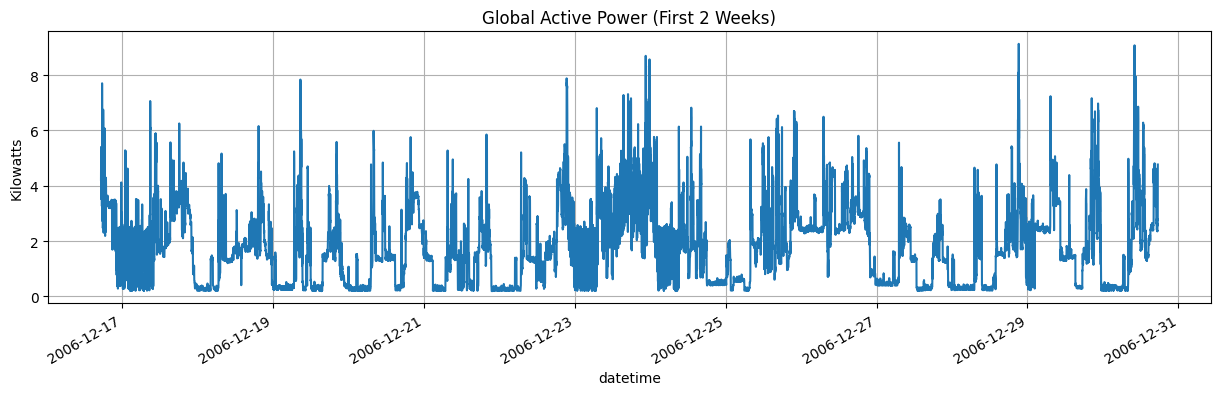

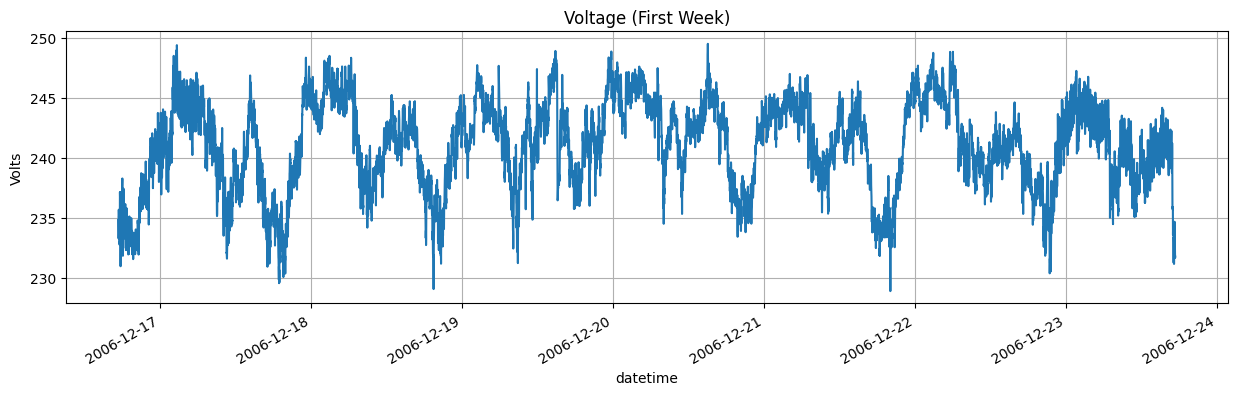

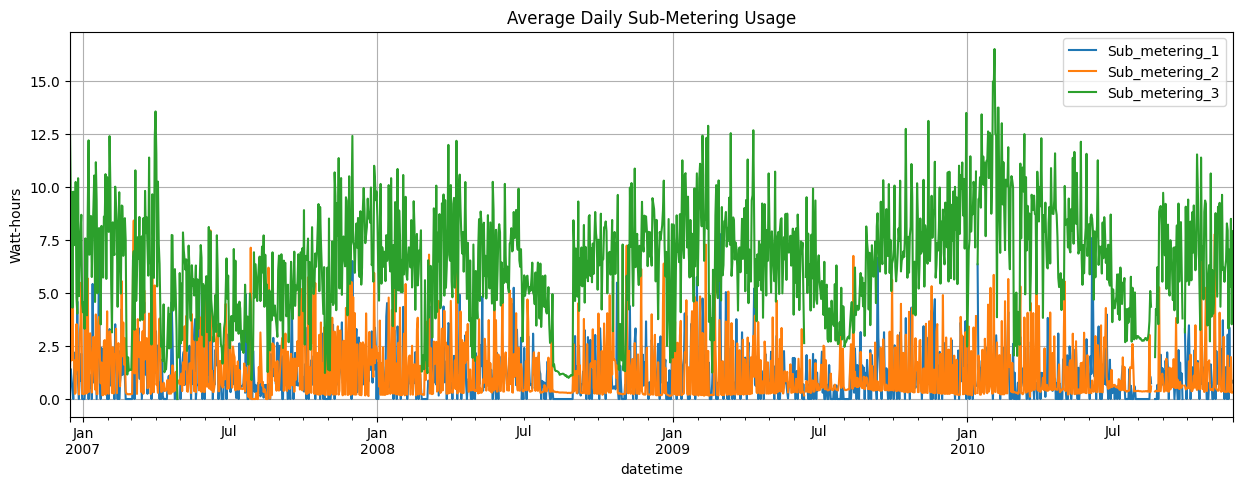

In [7]:
# 📊 Data Preview
print("Dataset shape:", df.shape)
df.head()

# 🕒 Ensure datetime index
df.index = pd.to_datetime(df.index)
df = df.sort_index()

# ❓ Missing values
print("Missing values:")
print(df.isna().sum())

# 📈 Global Active Power - First 2 Weeks
df['Global_active_power'].dropna().iloc[:60*24*14].plot(figsize=(15, 4), title='Global Active Power (First 2 Weeks)')
plt.ylabel('Kilowatts')
plt.grid()
plt.show()

# 🔋 Voltage - First Week
df['Voltage'].dropna().iloc[:60*24*7].plot(figsize=(15, 4), title='Voltage (First Week)')
plt.ylabel('Volts')
plt.grid()
plt.show()

# 🔌 Daily Average Sub-Metering
daily_metering = df[['Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']].resample('D').mean()
daily_metering.plot(figsize=(15,5), title='Average Daily Sub-Metering Usage')
plt.ylabel('Watt-hours')
plt.grid()
plt.show()


# Correlation & Distribution Insights

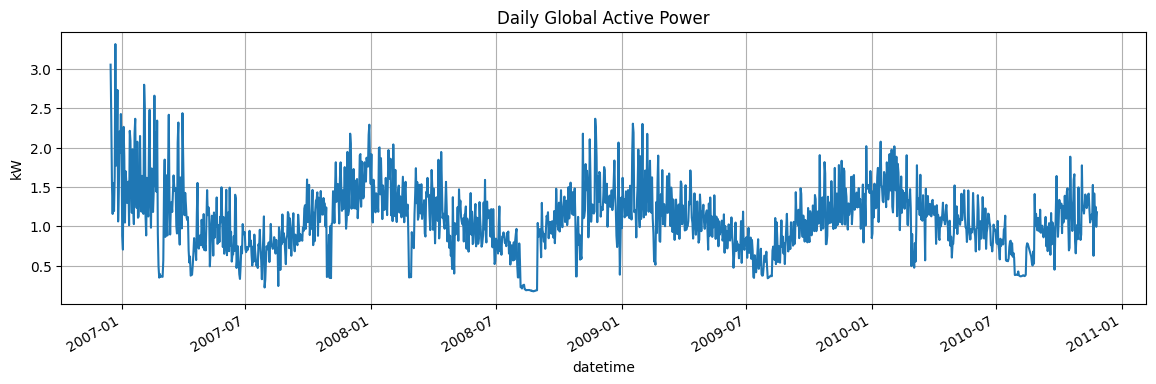

In [8]:

# Resample to daily average
df_daily = df['Global_active_power'].resample('D').mean().dropna()
df_daily = df_daily.to_frame(name='power')

# Plot
plt.figure(figsize=(14,4))
df_daily['power'].plot(title='Daily Global Active Power')
plt.ylabel('kW')
plt.grid()
plt.show()


# Anomaly Detection using Isolation Forest

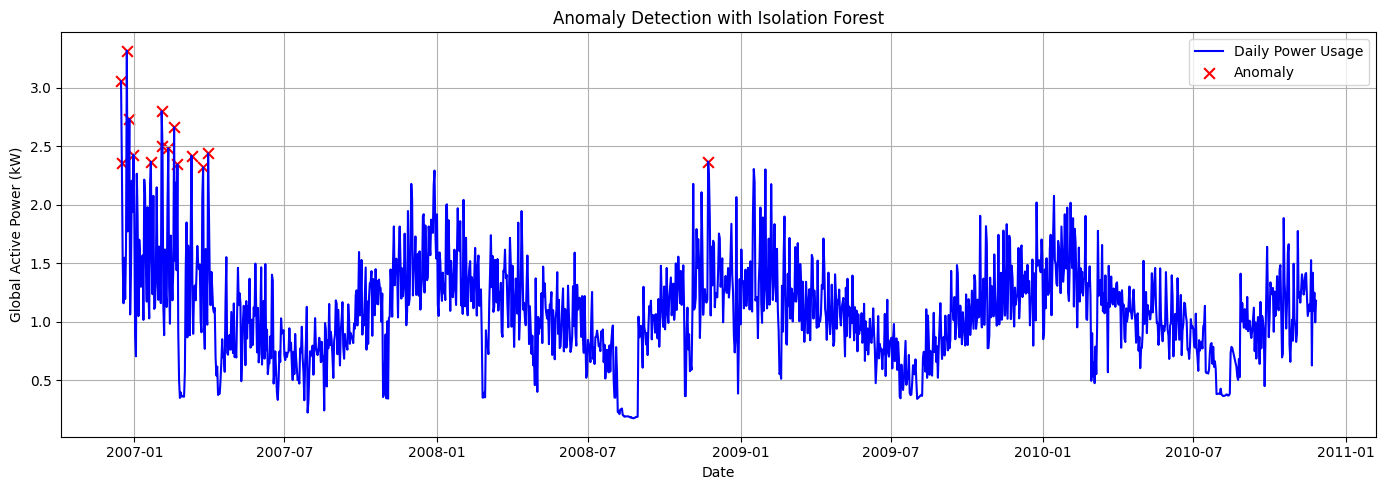

In [9]:

# Use daily average active power
df_daily = df['Global_active_power'].resample('D').mean().dropna()
df_daily = df_daily.to_frame(name='power')

# Apply Isolation Forest with tuned contamination
model = IsolationForest(n_estimators=200, contamination=0.01, random_state=42)
df_daily['anomaly'] = model.fit_predict(df_daily[['power']])  # -1 = anomaly, 1 = normal

# Plot detected anomalies
plt.figure(figsize=(14, 5))
plt.plot(df_daily.index, df_daily['power'], label='Daily Power Usage', color='blue')
plt.scatter(df_daily[df_daily['anomaly'] == -1].index,
            df_daily[df_daily['anomaly'] == -1]['power'],
            color='red', label='Anomaly', marker='x', s=60)
plt.title("Anomaly Detection with Isolation Forest")
plt.xlabel("Date")
plt.ylabel("Global Active Power (kW)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()



## Isolation Forest - Hypertuning (UsingGridsearchCV)

In [10]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import IsolationForest
import numpy as np

# Input data
X = df_daily[['power']].copy()

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'contamination': [0.005, 0.01, 0.02],
    'max_samples': ['auto', 0.6, 0.8]
}

# Time-aware split
tscv = TimeSeriesSplit(n_splits=5)

# Set up the model
iso_forest = IsolationForest(random_state=42)

# Use GridSearchCV
grid = GridSearchCV(
    iso_forest,
    param_grid,
    cv=tscv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
# Run the grid search
grid.fit(X)
# Get the best model
best_iso_model = grid.best_estimator_
# Apply to dataset
df_daily['anomaly'] = best_iso_model.predict(X)

print("✅ Best Parameters:", grid.best_params_)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
✅ Best Parameters: {'contamination': 0.005, 'max_samples': 'auto', 'n_estimators': 100}


# Isolation forest - Hyperparameter Tuning (Manual Tuning)

In [11]:

# Input data
X = df_daily[['power']].copy()

# Define parameter grid manually
param_grid = {
    'n_estimators': [100, 200],
    'contamination': [0.005, 0.01, 0.02],
    'max_samples': ['auto', 0.6]
}

best_model = None
best_params = None
best_anomaly_count = -1

# Try every combination
for n in param_grid['n_estimators']:
    for c in param_grid['contamination']:
        for m in param_grid['max_samples']:
            model = IsolationForest(n_estimators=n, contamination=c, max_samples=m, random_state=42)
            preds = model.fit_predict(X)
            anomalies = (preds == -1).sum()
            print(f"n_estimators={n}, contamination={c}, max_samples={m} ➜ Anomalies: {anomalies}")

            # Example heuristic: maximize anomaly count
            if anomalies > best_anomaly_count:
                best_anomaly_count = anomalies
                best_model = model
                best_params = {'n_estimators': n, 'contamination': c, 'max_samples': m}

# Apply best model
df_daily['iso_anomaly'] = best_model.fit_predict(X)
print("✅ Best Parameters (based on anomaly count):", best_params)


n_estimators=100, contamination=0.005, max_samples=auto ➜ Anomalies: 8
n_estimators=100, contamination=0.005, max_samples=0.6 ➜ Anomalies: 8
n_estimators=100, contamination=0.01, max_samples=auto ➜ Anomalies: 15
n_estimators=100, contamination=0.01, max_samples=0.6 ➜ Anomalies: 15
n_estimators=100, contamination=0.02, max_samples=auto ➜ Anomalies: 29
n_estimators=100, contamination=0.02, max_samples=0.6 ➜ Anomalies: 29
n_estimators=200, contamination=0.005, max_samples=auto ➜ Anomalies: 8
n_estimators=200, contamination=0.005, max_samples=0.6 ➜ Anomalies: 8
n_estimators=200, contamination=0.01, max_samples=auto ➜ Anomalies: 15
n_estimators=200, contamination=0.01, max_samples=0.6 ➜ Anomalies: 15
n_estimators=200, contamination=0.02, max_samples=auto ➜ Anomalies: 29
n_estimators=200, contamination=0.02, max_samples=0.6 ➜ Anomalies: 29
✅ Best Parameters (based on anomaly count): {'n_estimators': 100, 'contamination': 0.02, 'max_samples': 'auto'}


# Anomaly Detection using Local Outlier Factor (LOF)

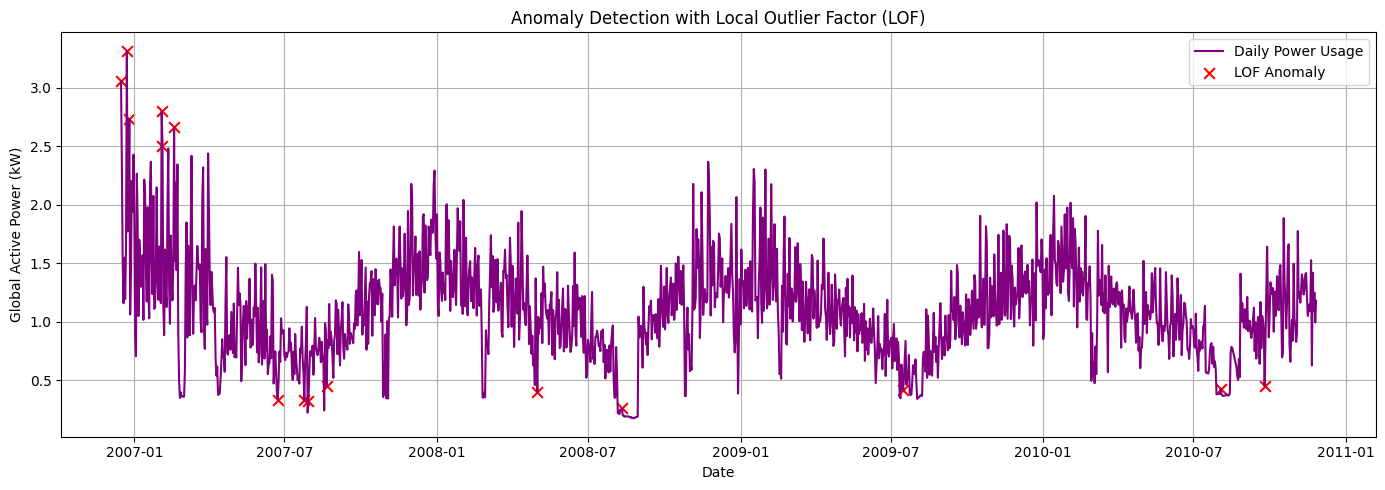

In [12]:

# Reuse your daily power dataset
X = df_daily[['power']].copy()

# Apply LOF
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.01)
df_daily['lof_anomaly'] = lof.fit_predict(X)  # -1 = anomaly

# Visualize LOF anomalies
plt.figure(figsize=(14, 5))
plt.plot(df_daily.index, df_daily['power'], label='Daily Power Usage', color='purple')
plt.scatter(df_daily[df_daily['lof_anomaly'] == -1].index,
            df_daily[df_daily['lof_anomaly'] == -1]['power'],
            color='Red', label='LOF Anomaly', marker='x', s=60)
plt.title("Anomaly Detection with Local Outlier Factor (LOF)")
plt.xlabel("Date")
plt.ylabel("Global Active Power (kW)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


# Anomaly Detection using Autoencoder (Deep Learning)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


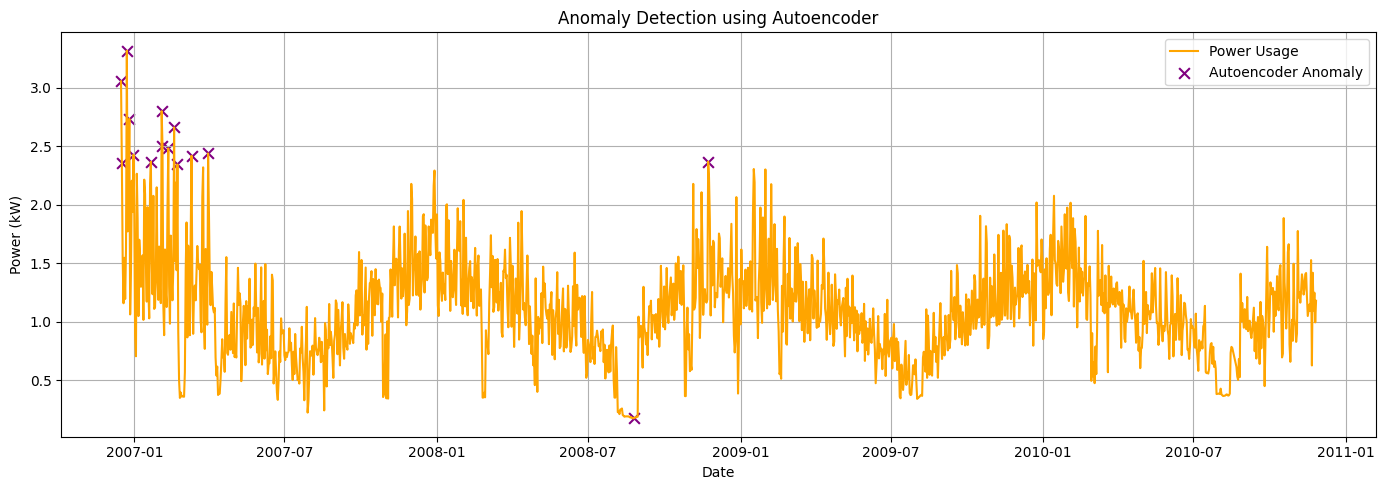

In [13]:

# Step 1: Normalize the data
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df_daily[['power']])

# Step 2: Define the Autoencoder model
autoencoder = Sequential([
    Dense(8, activation='relu', input_shape=(1,)),
    Dense(4, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='linear')
])

autoencoder.compile(optimizer='adam', loss='mse')

# Step 3: Train the model
history = autoencoder.fit(X_scaled, X_scaled, epochs=100, batch_size=16, verbose=0, validation_split=0.1)

# Step 4: Reconstruct and calculate reconstruction error
X_pred = autoencoder.predict(X_scaled)
mse = np.mean(np.square(X_scaled - X_pred), axis=1)

# Step 5: Set threshold and label anomalies
threshold = np.percentile(mse, 99)
df_daily['auto_mse'] = mse
df_daily['auto_anomaly'] = (mse > threshold).astype(int)

# Step 6: Plot results
plt.figure(figsize=(14, 5))
plt.plot(df_daily.index, df_daily['power'], label='Power Usage', color='Orange')
plt.scatter(df_daily[df_daily['auto_anomaly'] == 1].index,
            df_daily[df_daily['auto_anomaly'] == 1]['power'],
            color='purple', label='Autoencoder Anomaly', marker='x', s=60)
plt.title("Anomaly Detection using Autoencoder")
plt.xlabel("Date")
plt.ylabel("Power (kW)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


# Auto encoder hyperparameter tuning

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


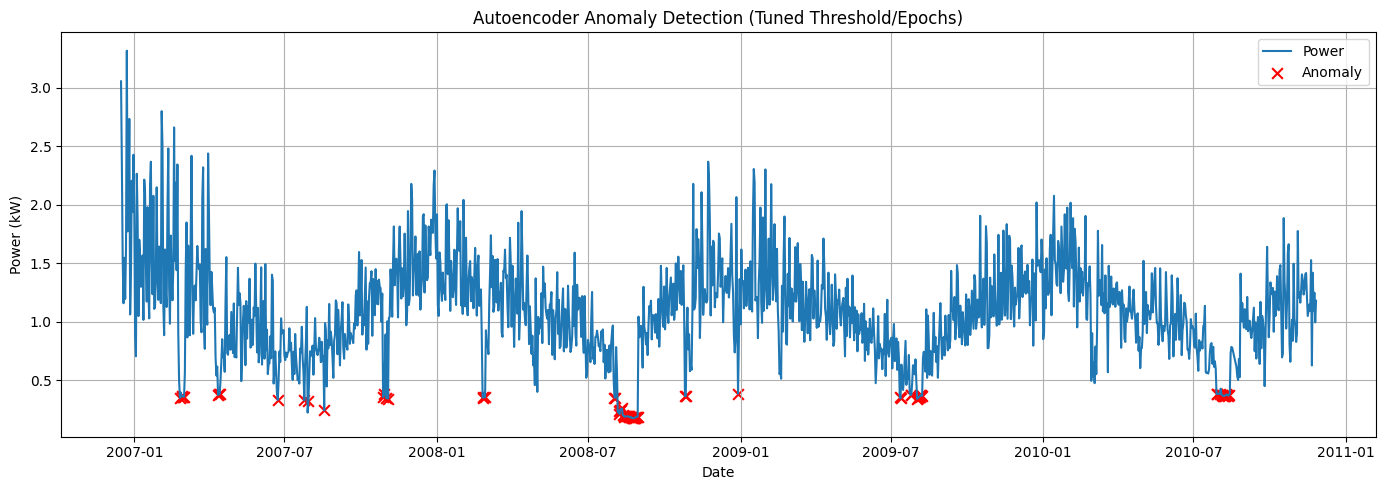

In [14]:
# Autoencoder Training with Tuned Hyperparameters

# Normalize input (if not already done)
X = df_daily[['power']].values
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)


# 🚀 Tune training hyperparameters
history = autoencoder.fit(
    X_scaled, X_scaled,
    epochs=150,
    batch_size=32,
    validation_split=0.1,
    verbose=0
)

# Predict and calculate reconstruction error
X_pred = autoencoder.predict(X_scaled)
recon_error = np.mean(np.square(X_scaled - X_pred), axis=1)

# 🔧 Tune threshold (95th percentile)
threshold = np.percentile(recon_error, 95)  # Try 90 or 99 for comparison
df_daily['ae_mse'] = recon_error
df_daily['ae_anomaly'] = (recon_error > threshold).astype(int)

# Plotting
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 5))
plt.plot(df_daily.index, df_daily['power'], label='Power')
plt.scatter(df_daily[df_daily['ae_anomaly'] == 1].index,
            df_daily[df_daily['ae_anomaly'] == 1]['power'],
            color='red', marker='x', s=60, label='Anomaly')
plt.title("Autoencoder Anomaly Detection (Tuned Threshold/Epochs)")
plt.xlabel("Date")
plt.ylabel("Power (kW)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


# Visual & Quantitative Comparison of All Methods

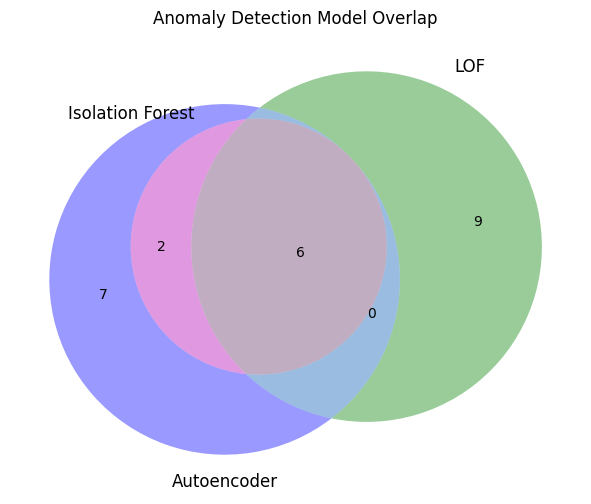

In [15]:

# Step 1: Count anomalies
iso_anomalies = set(df_daily[df_daily['anomaly'] == -1].index)
lof_anomalies = set(df_daily[df_daily['lof_anomaly'] == -1].index)
auto_anomalies = set(df_daily[df_daily['auto_anomaly'] == 1].index)

# Step 2: Venn Diagram
plt.figure(figsize=(8, 6))
venn3([iso_anomalies, lof_anomalies, auto_anomalies],
      set_labels=('Isolation Forest', 'LOF', 'Autoencoder'))
plt.title("Anomaly Detection Model Overlap")
plt.show()


# Bar Chart of Counts

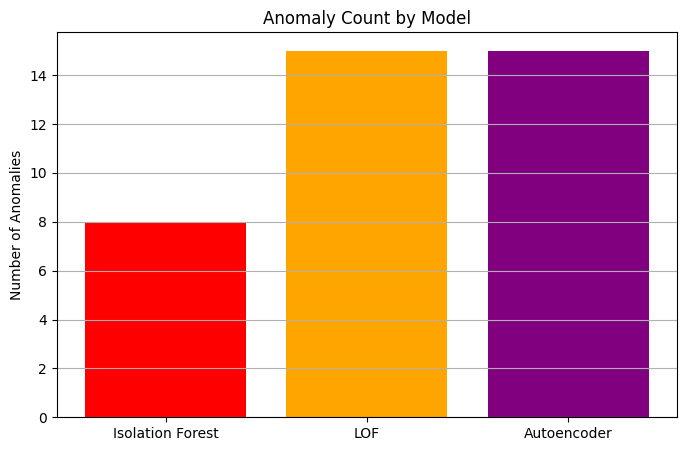

In [16]:
# Count how many anomalies each model detected
counts = {
    'Isolation Forest': len(iso_anomalies),
    'LOF': len(lof_anomalies),
    'Autoencoder': len(auto_anomalies)
}

plt.figure(figsize=(8, 5))
plt.bar(counts.keys(), counts.values(), color=['Red', 'orange', 'purple'])
plt.ylabel("Number of Anomalies")
plt.title("Anomaly Count by Model")
plt.grid(axis='y')
plt.show()


## Smart Consumption Profiling (Clustering)

In [17]:
# Extract daily features for clustering and classification
df_features = df.resample('D').agg({
    'Global_active_power': 'mean',
    'Voltage': 'mean',
    'Global_intensity': 'mean',
    'Sub_metering_1': 'mean',
    'Sub_metering_2': 'mean',
    'Sub_metering_3': 'mean'
}).dropna()

display(df_features.head())

,Global_active_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,
2006-12-16,3.053475,236.243763,13.082828,0.000000,1.378788,12.439394
2006-12-17,2.354486,240.087028,9.999028,1.411806,2.907639,9.264583
2006-12-18,1.530435,241.231694,6.421667,0.738194,1.820139,9.734722
2006-12-19,1.157079,241.999313,4.926389,0.582639,5.279167,4.303472
2006-12-20,1.545658,242.308062,6.467361,0.000000,1.838889,9.765972


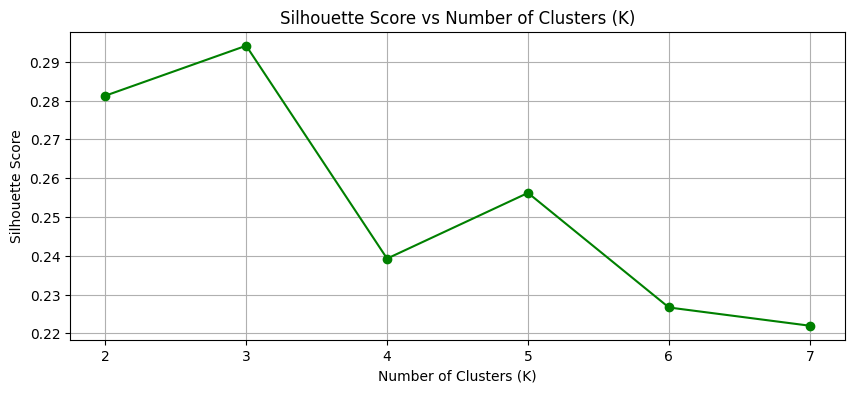

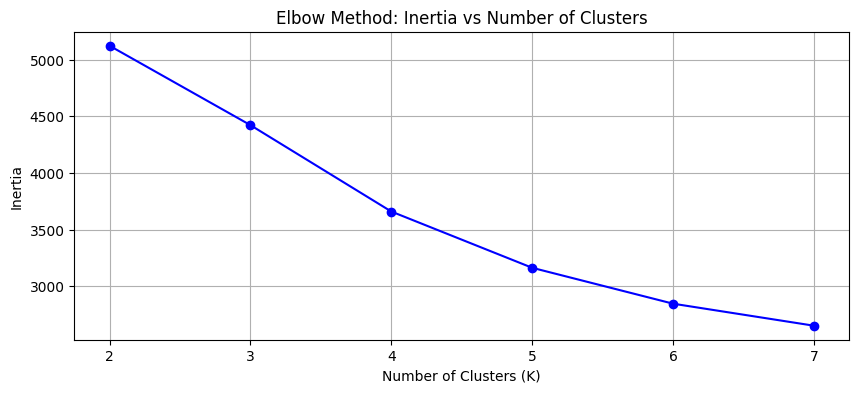

In [18]:
# Scale the clustering features
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score # Import silhouette_score

clustering_features = df_features[['Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'Voltage', 'Global_intensity']].dropna()
scaled = StandardScaler().fit_transform(clustering_features)

# Range of K values to test
range_k = range(2, 8)
inertias = []
silhouette_scores = []

for k in range_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(scaled, labels))

# Plot Silhouette Score
plt.figure(figsize=(10, 4))
plt.plot(range_k, silhouette_scores, marker='o', color='green')
plt.title("Silhouette Score vs Number of Clusters (K)")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

# Plot Elbow (Inertia)
plt.figure(figsize=(10, 4))
plt.plot(range_k, inertias, marker='o', color='blue')
plt.title("Elbow Method: Inertia vs Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

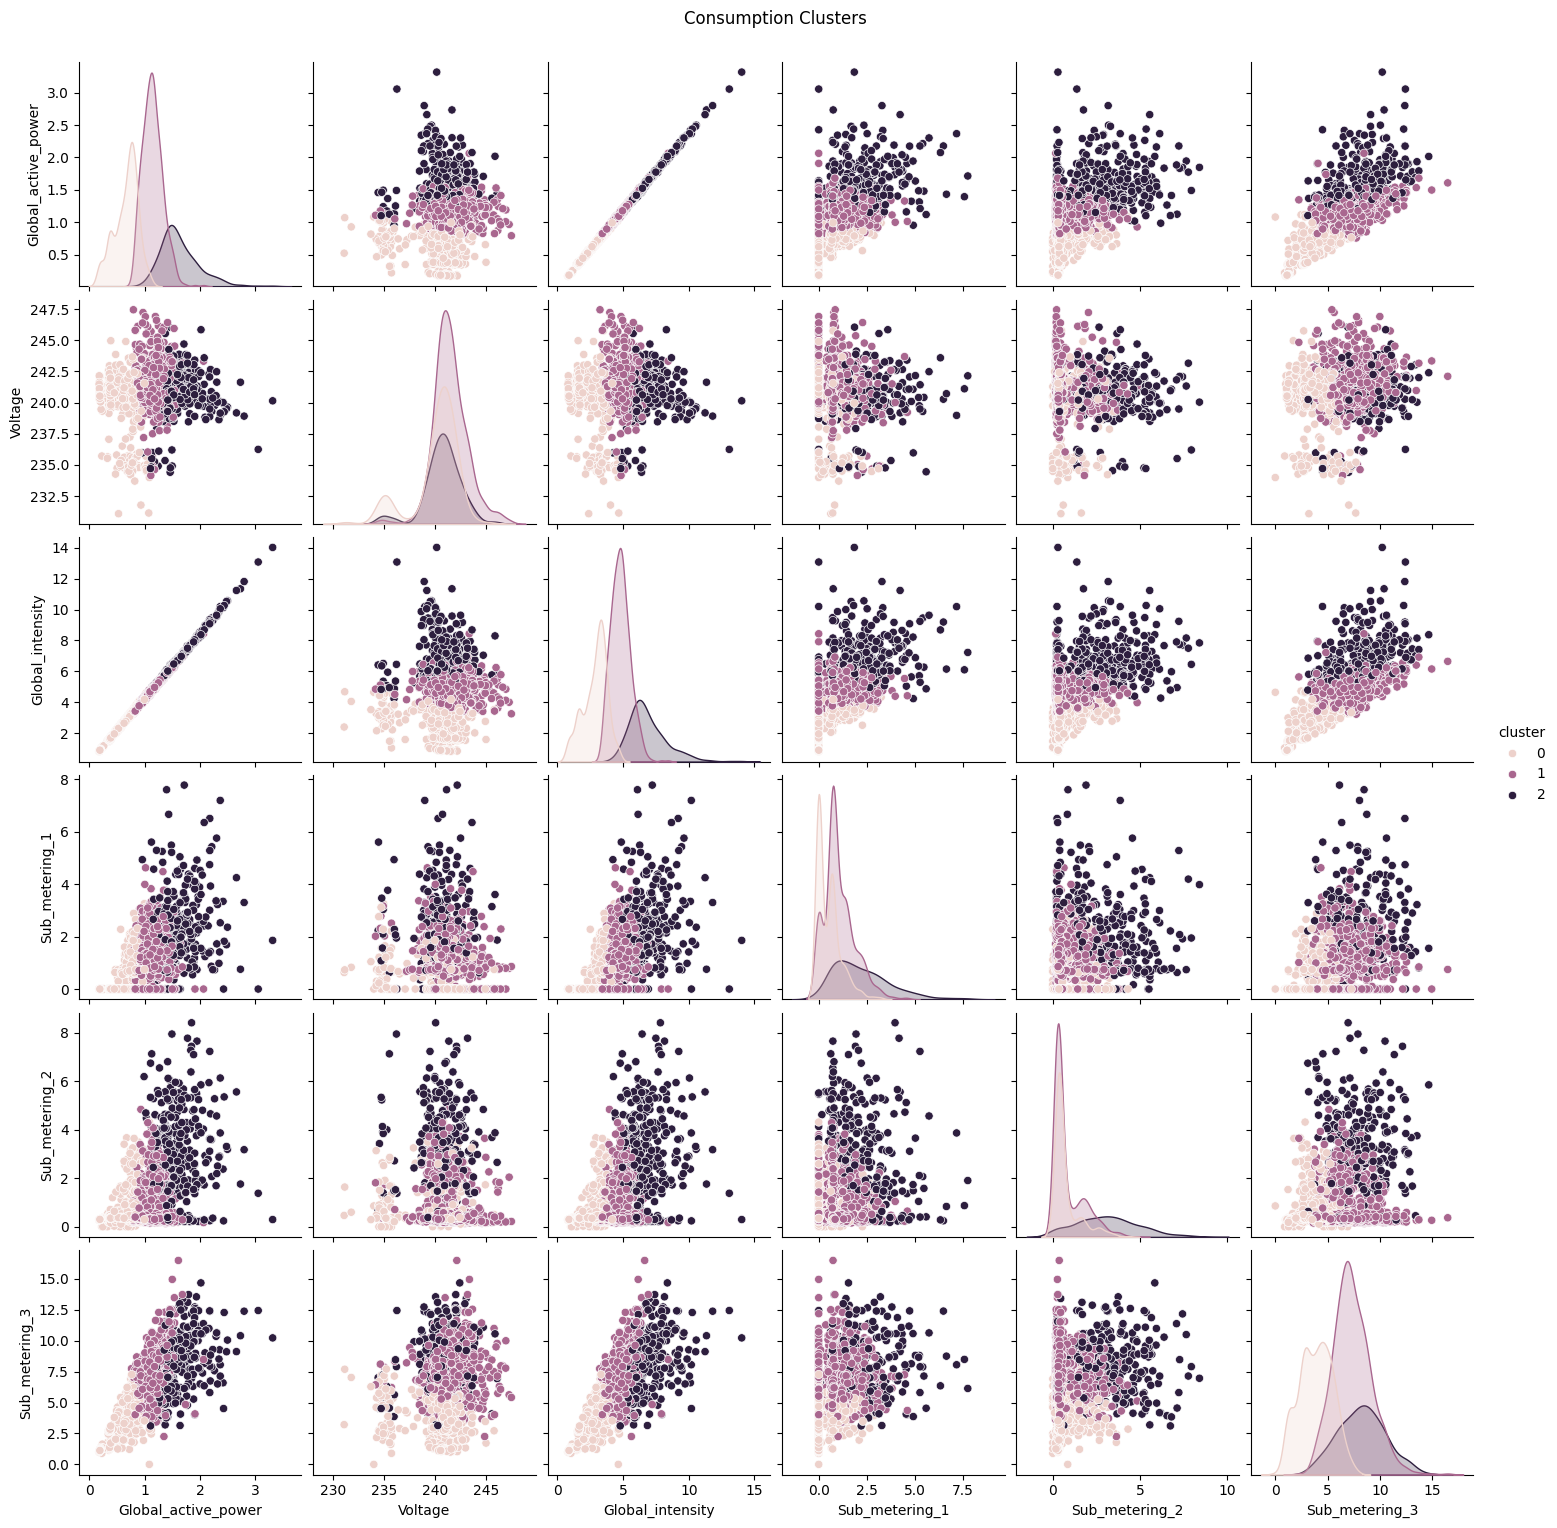

In [19]:

# Extract daily features
df_features = df.resample('D').agg({
    'Global_active_power': 'mean',
    'Voltage': 'mean',
    'Global_intensity': 'mean',
    'Sub_metering_1': 'mean',
    'Sub_metering_2': 'mean',
    'Sub_metering_3': 'mean'
}).dropna()

# Normalize features
scaler = StandardScaler()
scaled = scaler.fit_transform(df_features)

# KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
df_features['cluster'] = kmeans.fit_predict(scaled)

# Visualize clusters
sns.pairplot(df_features.reset_index(), hue='cluster', vars=df_features.columns[:-1])
plt.suptitle("Consumption Clusters", y=1.02)
plt.show()


# 🚀 Binary Classification of Daily Energy Usage (High vs Low) using Random Forest


Fitting 5 folds for each of 36 candidates, totalling 180 fits
✅ Best Random Forest Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 100}


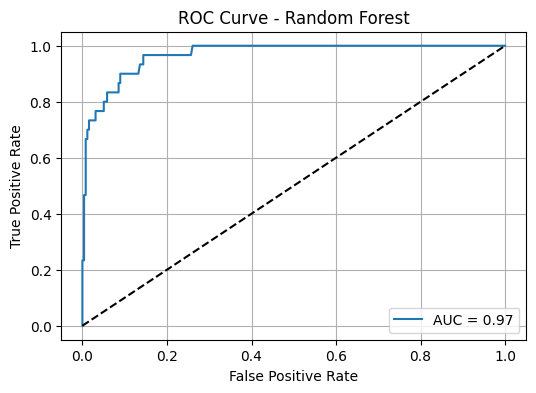

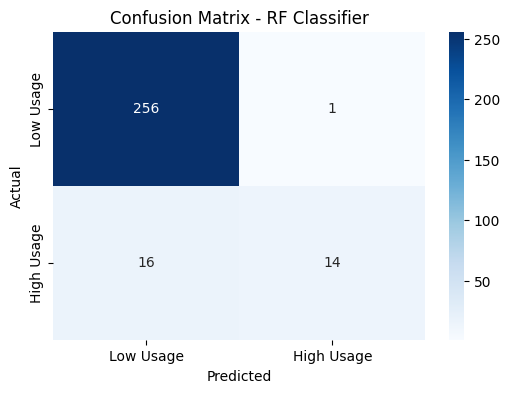

✅ Accuracy: 0.9407665505226481

Classification Report:
               precision    recall  f1-score   support

   Low Usage       0.94      1.00      0.97       257
  High Usage       0.93      0.47      0.62        30

    accuracy                           0.94       287
   macro avg       0.94      0.73      0.80       287
weighted avg       0.94      0.94      0.93       287



In [20]:
# ✅ Corrected Classification Setup with ROC & Confusion Matrix (No Prophet)

# 1. Create target
# Define spike-based target using rolling window
df_features['rolling_mean_power'] = df_features['Global_active_power'].rolling(window=7, min_periods=1).mean()
df_features['target'] = (df_features['Global_active_power'] > 1.3 * df_features['rolling_mean_power']).astype(int)



X = df_features.drop(columns=['target', 'Global_active_power'])
y = df_features['target']

# 3. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Train classifier
# 🚀 Random Forest Hyperparameter Tuning with GridSearchCV

param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 4],
    'min_samples_leaf': [1, 2]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rfc = RandomForestClassifier(random_state=42)
grid_search_rf = GridSearchCV(estimator=rfc,
                                 param_grid=param_grid,
                                 cv=cv,
                                 scoring='accuracy',
                                 n_jobs=-1,
                                 verbose=1)

grid_search_rf.fit(X_train, y_train)

# Best model and predictions
best_rf = grid_search_rf.best_estimator_
y_pred = best_rf.predict(X_test)
y_scores = best_rf.predict_proba(X_test)[:, 1]

print("✅ Best Random Forest Parameters:", grid_search_rf.best_params_)


# 5. Predictions


y_pred = best_rf.predict(X_test) # Corrected: Use best_rf for prediction
y_scores = best_rf.predict_proba(X_test)[:, 1] # Corrected: Use best_rf for prediction

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.grid()
plt.show()

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
              xticklabels=['Low Usage', 'High Usage'],
              yticklabels=['Low Usage', 'High Usage'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - RF Classifier")
plt.show()

# Evaluation
print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=['Low Usage', 'High Usage']))

# Load Forecasting with Prophet

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpflr1xsdf/d0noya34.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpflr1xsdf/1swb3vsw.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=56985', 'data', 'file=/tmp/tmpflr1xsdf/d0noya34.json', 'init=/tmp/tmpflr1xsdf/1swb3vsw.json', 'output', 'file=/tmp/tmpflr1xsdf/prophet_modelqksgqf91/prophet_model-20250828065408.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
06:54:08 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
06:54:08 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


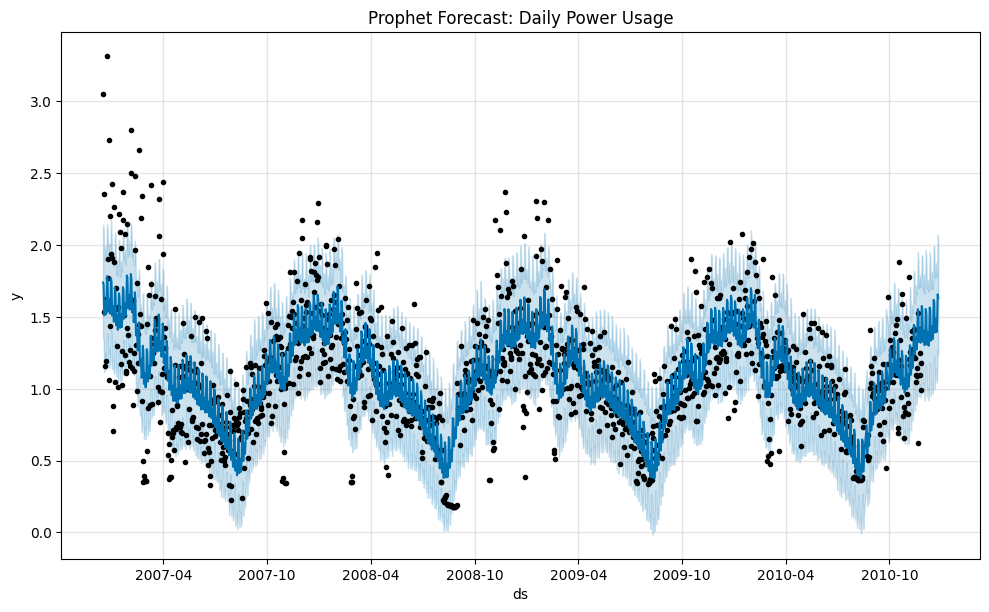

MAE: 0.31326237290310477
RMSE: 0.37719443762250604


In [21]:
df_prophet = df_daily.reset_index().rename(columns={'datetime': 'ds', 'power': 'y'})
model = Prophet()
model.fit(df_prophet)

# Forecast 30 days ahead
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

# Plot forecast
model.plot(forecast)
plt.title('Prophet Forecast: Daily Power Usage')
plt.show()

# Evaluate last 30 days
y_true = df_prophet['y'][-30:]
y_pred = forecast['yhat'][-30:]
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

# Prophet Model – Manual Parameter Tuning

DEBUG:cmdstanpy:input tempfile: /tmp/tmpflr1xsdf/_e1xxakq.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpflr1xsdf/ue7h6ybm.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=94071', 'data', 'file=/tmp/tmpflr1xsdf/_e1xxakq.json', 'init=/tmp/tmpflr1xsdf/ue7h6ybm.json', 'output', 'file=/tmp/tmpflr1xsdf/prophet_modelwi3babx0/prophet_model-20250828065409.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
06:54:09 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
06:54:09 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


✅ Prophet MAE: 0.201614869915111
✅ Prophet RMSE: 0.26381016657294154


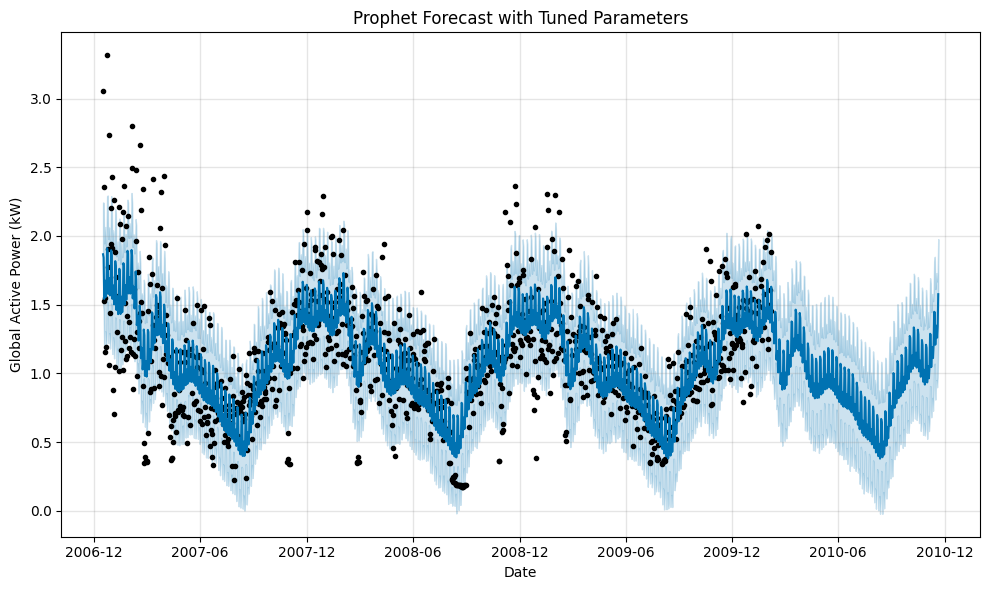

In [22]:

# 1. Prepare daily data
df_prophet = df[['Global_active_power']].resample('D').mean().dropna().reset_index()
df_prophet.columns = ['ds', 'y']

# 2. Train/test split
train_size = int(len(df_prophet) * 0.8)
train = df_prophet.iloc[:train_size]
test = df_prophet.iloc[train_size:]

# 3. Initialize Prophet with tuned parameters
model = Prophet(
    changepoint_prior_scale=0.1,          # makes trend more flexible
    seasonality_prior_scale=10,           # allows more seasonal influence
    seasonality_mode='multiplicative',    # assume seasonal growth pattern
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

# 4. Fit and predict
model.fit(train)
future = model.make_future_dataframe(periods=len(test))
forecast = model.predict(future)

# 5. Evaluate
y_true = test['y'].values
y_pred = forecast.iloc[-len(test):]['yhat'].values
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print("✅ Prophet MAE:", mae)
print("✅ Prophet RMSE:", rmse)

# 6. Plot forecast
model.plot(forecast)
plt.title("Prophet Forecast with Tuned Parameters")
plt.xlabel("Date")
plt.ylabel("Global Active Power (kW)")
plt.grid(True)
plt.tight_layout()
plt.show()
